# REPLYNT Notebook 3: Intent Classifier

This notebook predicts the intent class for incoming email. It uses TF-IDF text features with a balanced LinearSVC, handles rare classes by adapting the number of stratified folds, reports evaluation metrics, surfaces the most common confusion pairs, and saves the trained pipeline as `intent_pipeline.pkl`.

In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
}

missing = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(package_name)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All base packages are already installed.")

All base packages are already installed.


In [2]:
from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42
BASE_DIR = Path.home() / "Desktop" / "replynt_final"
DATA_DIR = BASE_DIR / "data"
NOTEBOOK_DIR = BASE_DIR / "notebooks"
MODELS_DIR = BASE_DIR / "models"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Model directory: {MODELS_DIR}")

Data directory: C:\Users\mbmeg\Desktop\replynt_final\data
Notebook directory: C:\Users\mbmeg\Desktop\replynt_final\notebooks
Model directory: C:\Users\mbmeg\Desktop\replynt_final\models


In [3]:
def normalize_text(value: str) -> str:
    if pd.isna(value):
        return ""
    text = str(value).replace("\r", " ").replace("\n", " ")
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text, flags=re.IGNORECASE)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    text = re.sub(r"[^a-zA-Z0-9$%!?.,:/\\-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def detect_csv(candidates: Iterable[str], required_columns: Iterable[str]) -> Path:
    required_columns = set(required_columns)
    candidates = [candidate.lower() for candidate in candidates]
    files = sorted(DATA_DIR.glob("*.csv"))

    for path in files:
        if any(candidate in path.name.lower() for candidate in candidates):
            preview = pd.read_csv(path, nrows=5)
            if required_columns.issubset(set(preview.columns)):
                return path

    for path in files:
        preview = pd.read_csv(path, nrows=5)
        if required_columns.issubset(set(preview.columns)):
            return path

    raise FileNotFoundError(
        f"Could not find a CSV in {DATA_DIR} matching names={candidates} and columns={sorted(required_columns)}"
    )


def safe_n_splits(y: pd.Series, default: int = 5) -> int:
    return max(2, min(default, int(y.value_counts().min())))


def metrics_frame(y_true, y_pred, average="macro") -> pd.DataFrame:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
    }
    return pd.DataFrame([metrics]).round(4)


def plot_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return cm_df


def summarize_cv(results: dict, model_name: str) -> pd.DataFrame:
    frame = pd.DataFrame(results)
    keep = [col for col in frame.columns if col.startswith("test_")]
    summary = frame[keep].agg(["mean", "std"]).T.reset_index()
    summary.columns = ["metric", f"{model_name}_mean", f"{model_name}_std"]
    summary["metric"] = summary["metric"].str.replace("test_", "", regex=False)
    return summary

intent_path = detect_csv(["triage", "intent"], ["subject", "body", "intent"])
print(f"Using dataset: {intent_path}")

df = pd.read_csv(intent_path)
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")
df["email_text"] = (df["subject"].astype(str) + " " + df["body"].astype(str)).map(normalize_text)
df["intent"] = df["intent"].astype(str).str.strip()
df = df[df["intent"].ne("")].reset_index(drop=True)

counts = df["intent"].value_counts()
rare_classes = counts[counts < 5]
display(counts.to_frame("count"))
if rare_classes.empty:
    print("No intent classes have fewer than 5 examples.")
else:
    print("Rare classes detected. Stratified folds will be reduced automatically.")
    display(rare_classes.to_frame("count"))

Using dataset: C:\Users\mbmeg\Desktop\replynt_final\data\triage_train_FINAL.csv


,count
intent,
Product Update,934
Payment Reminder,930
Support Request,880
Meeting Request,828
Sales Outreach,819
Complaint,781
Interview Request,749
Investor Interest,748
Follow Up,651


No intent classes have fewer than 5 examples.


In [4]:
X = df[["email_text"]].copy()
y = df["intent"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(
    n_splits=safe_n_splits(y_train, default=5),
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [5]:
intent_pipeline = Pipeline(
    steps=[
        (
            "features",
            ColumnTransformer(
                transformers=[
                    (
                        "text",
                        TfidfVectorizer(
                            ngram_range=(1, 2),
                            min_df=2,
                            max_df=0.98,
                            sublinear_tf=True,
                            strip_accents="unicode",
                        ),
                        "email_text",
                    )
                ]
            ),
        ),
        ("classifier", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
}

cv_results = cross_validate(intent_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
display(summarize_cv(cv_results, "LinearSVC").round(4))

,metric,LinearSVC_mean,LinearSVC_std
0,accuracy,0.9772,0.0024
1,precision,0.9817,0.0018
2,recall,0.9768,0.0026
3,f1,0.9784,0.0024


,accuracy,precision,recall,f1
0,0.9768,0.9814,0.9768,0.9783


                   precision    recall  f1-score   support

        Complaint       0.99      0.88      0.93       156
        Follow Up       0.96      0.88      0.92       130
     Internal FYI       1.00      1.00      1.00        91
Interview Request       1.00      1.00      1.00       150
Investor Interest       1.00      1.00      1.00       150
  Meeting Request       1.00      1.00      1.00       166
       Newsletter       1.00      1.00      1.00        88
 Payment Reminder       1.00      1.00      1.00       186
   Product Update       1.00      1.00      1.00       187
    Quote Request       1.00      1.00      1.00       120
   Sales Outreach       1.00      1.00      1.00       164
  Support Request       0.83      0.97      0.89       176

         accuracy                           0.98      1764
        macro avg       0.98      0.98      0.98      1764
     weighted avg       0.98      0.98      0.98      1764



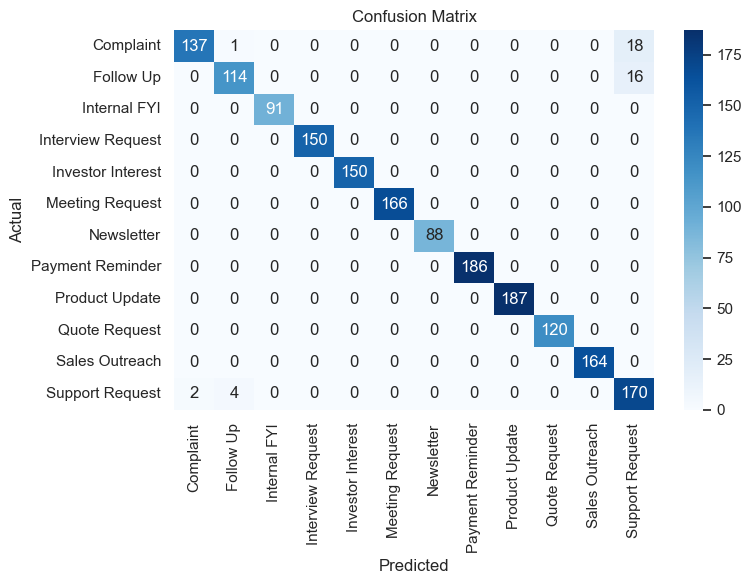

,Complaint,Follow Up,Internal FYI,Interview Request,Investor Interest,Meeting Request,Newsletter,Payment Reminder,Product Update,Quote Request,Sales Outreach,Support Request
Complaint,137,1,0,0,0,0,0,0,0,0,0,18
Follow Up,0,114,0,0,0,0,0,0,0,0,0,16
Internal FYI,0,0,91,0,0,0,0,0,0,0,0,0
Interview Request,0,0,0,150,0,0,0,0,0,0,0,0
Investor Interest,0,0,0,0,150,0,0,0,0,0,0,0
Meeting Request,0,0,0,0,0,166,0,0,0,0,0,0
Newsletter,0,0,0,0,0,0,88,0,0,0,0,0
Payment Reminder,0,0,0,0,0,0,0,186,0,0,0,0
Product Update,0,0,0,0,0,0,0,0,187,0,0,0
Quote Request,0,0,0,0,0,0,0,0,0,120,0,0


In [6]:
intent_pipeline.fit(X_train, y_train)
y_pred = intent_pipeline.predict(X_test)

display(metrics_frame(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred, zero_division=0))
labels = sorted(y_train.unique())
confusion_df = plot_confusion(y_test, y_pred, labels=labels)
display(confusion_df)

## Top Confusion Classes

The most frequent off-diagonal pairs tell us which intents are hardest to separate and where more data or business heuristics may help.

In [7]:
confusions = []
for actual in confusion_df.index:
    for predicted in confusion_df.columns:
        if actual != predicted and confusion_df.loc[actual, predicted] > 0:
            confusions.append(
                {"actual": actual, "predicted": predicted, "count": int(confusion_df.loc[actual, predicted])}
            )

confusion_pairs = pd.DataFrame(confusions).sort_values("count", ascending=False)
display(confusion_pairs.head(10))

,actual,predicted,count
1,Complaint,Support Request,18
2,Follow Up,Support Request,16
4,Support Request,Follow Up,4
3,Support Request,Complaint,2
0,Complaint,Follow Up,1


In [8]:
feature_names = intent_pipeline.named_steps["features"].get_feature_names_out()
classifier = intent_pipeline.named_steps["classifier"]
coef_frame = pd.DataFrame(classifier.coef_.T, index=feature_names, columns=classifier.classes_)

for label in classifier.classes_:
    print(f"Top features for {label}")
    display(coef_frame[label].sort_values(ascending=False).head(15).reset_index().rename(columns={"index": "feature", label: "weight"}))

Top features for Complaint


,feature,weight
0,text__breach,3.098234
1,text__outage,1.994649
2,text__failure,1.694366
3,text__data breach,1.372595
4,text__delay,1.298582
5,text__security breach,1.222991
6,text__failed,1.196082
7,text__failed to,1.187776
8,text__delayed,0.918794
9,text__an,0.834148


Top features for Follow Up


,feature,weight
0,text__up on,1.227550
1,text__following up,1.186962
2,text__details,0.866305
3,text__following,0.797185
4,text__this will,0.775170
5,text__can you,0.764211
6,text__dear customer,0.750763
7,text__tools could,0.745990
8,text__checking,0.724510
9,text__relevant,0.718046


Top features for Internal FYI


...

,feature,weight
0,text__quote,2.020290
1,text__quote for,1.443731
2,text__pricing,1.210852
3,text__budget request,0.696921
4,text__share pricing,0.691248
5,text__line item,0.678911
6,text__line,0.658170
7,text__before,0.620483
8,text__pricing for,0.615629
9,text__quote request,0.609087


Top features for Sales Outreach


,feature,weight
0,text__idea to,0.843949
1,text__idea,0.839185
2,text__teams,0.833170
3,text__improve,0.793760
4,text__help,0.757554
5,text__teams like,0.707606
6,text__can share,0.671620
7,text__useful,0.621711
8,text__we help,0.561906
9,text__like,0.548547


Top features for Support Request


,feature,weight
0,text__with,1.043173
1,text__hello support,0.948384
2,text__issues,0.882524
3,text__support request,0.865117
4,text__management,0.858902
5,text__problem with,0.820231
6,text__after,0.800901
7,text__existing,0.783976
8,text__investment,0.780860
9,text__saas platform,0.769223


In [9]:
model_path = MODELS_DIR / "intent_pipeline.pkl"
joblib.dump(intent_pipeline, model_path)
print(f"Saved model to: {model_path}")

Saved model to: C:\Users\mbmeg\Desktop\replynt_final\models\intent_pipeline.pkl


In [10]:
sample_email = pd.DataFrame(
    {"email_text": [normalize_text("Can we set up a 30-minute meeting tomorrow to review the contract status?")]}
)

sample_output = sample_email.copy()
sample_output["predicted_intent"] = intent_pipeline.predict(sample_email)
display(sample_output)

,email_text,predicted_intent
0,can we set up a 30-minute meeting tomorrow to review the contract status?,Meeting Request
